# Employment Statistics Visualization for AI, Data Science, and Software Development

In [76]:
## Importing Libraries and Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_excel('all_data_M_2023.xlsx', sheet_name = "All May 2023 data")
data.head(5)


,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,23.11,37.01,58.4,29050,35660,48060,76980,121470,NaN,NaN
1,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,56.19,81.29,111.36,54550,78330,116880,169090,231620,NaN,NaN
2,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1000,Top Executives,...,49.74,79.57,#,46400,66170,103460,165500,#,NaN,NaN
3,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1010,Chief Executives,...,99.37,#,#,80000,130840,206680,#,#,NaN,NaN
4,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,99.37,#,#,80000,130840,206680,#,#,NaN,NaN


## Filtering data
#### Now i will filter job titles from column OCC_TITLE with a word to get every job name that match the word e.g 'software'

In [90]:
# Filter occupations that contain the word 'Software' in OCC_TITLE
software_related_fields = data[data['OCC_TITLE'].str.contains('Software', case=False, na=False)]

# Display the filtered list of occupations related to Software
software_related_fields[['OCC_TITLE']].drop_duplicates()

,OCC_TITLE
147,"Software and Web Developers, Programmers, and ..."
149,Software Developers
150,Software Quality Assurance Analysts and Testers


 #### Using the same above command with different key words like [AI,Artifical Intelligence,Software,Developer,Data,Computer ]
 #### The following code is finalized from the results of running different word for job
 #### By doing this step i will filter job from data whom i would like to work 
 ### Note that any other job title can be added to below givin filter rest will work 
 (i couldnt see any other directly saying Ai job so i choose six) Some are just to compare jobs or things just to IT sectore

In [132]:
# filtering the field by word in titles and doing case ignore to math both uper and lower and ignoring NA values
filtered_data = data[data['OCC_TITLE'].str.contains('Software|Data Scientists|Developers|Computer Programmers',case=False,na = False)]
filtered_data[['OCC_TITLE']].drop_duplicates()

,OCC_TITLE
147,"Software and Web Developers, Programmers, and ..."
148,Computer Programmers
149,Software Developers
150,Software Quality Assurance Analysts and Testers
151,Web Developers
164,Data Scientists


## Question 1 
## what are the total number of employees from the filterd data across different field?


Total Employees in Filtered Data: 28258310.0


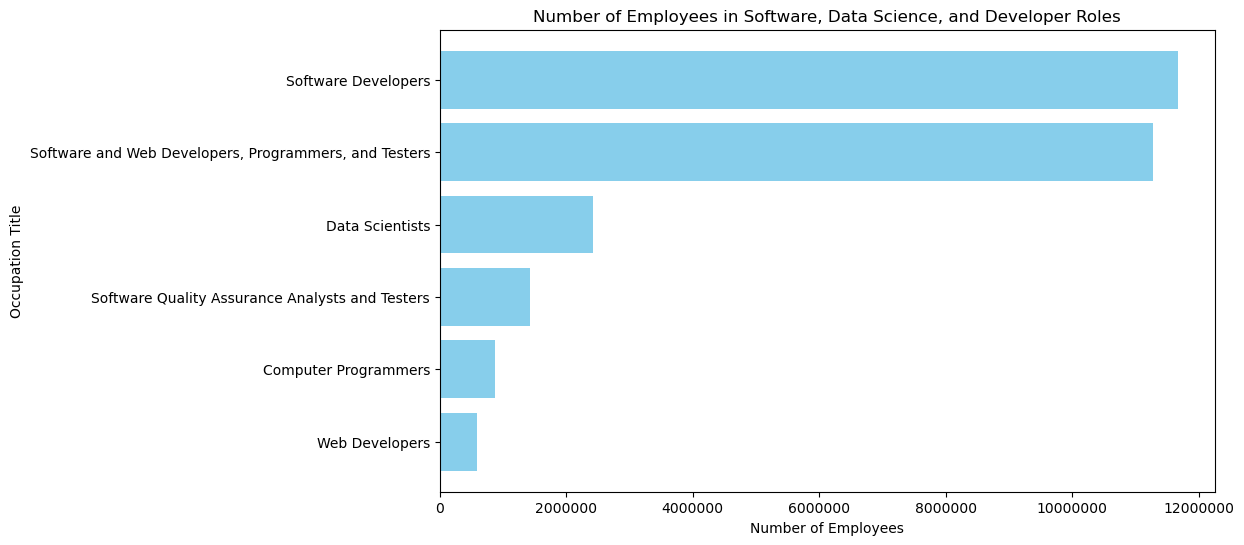

In [135]:
# will total number of employees in the selected/filtered fields 
# frist we have to change the type of column to numeric as its currently obj
# then we will sumup the number 
# draw the bar plot 

#there was unconverted value errors is used to replace them to na
filtered_data.loc[:, 'TOT_EMP'] = pd.to_numeric(filtered_data['TOT_EMP'], errors='coerce')
# Check the total number of employees in the filtered dataset
total_employees = filtered_data['TOT_EMP'].sum()
print(f"\nTotal Employees in Filtered Data: {total_employees}")
# Group by OCC_TITLE and sum the TOT_EMP column
employment_data = filtered_data.groupby('OCC_TITLE')['TOT_EMP'].sum().reset_index()

# Sort by the number of employees for better visualization
employment_data = employment_data.sort_values(by='TOT_EMP')

# Create a simple bar plot for the total number of employees
plt.figure(figsize=(10, 6))
plt.barh(employment_data['OCC_TITLE'], employment_data['TOT_EMP'], color='skyblue')
plt.xlabel('Number of Employees')
plt.ylabel('Occupation Title')
plt.title('Number of Employees in Software, Data Science, and Developer Roles')
 # Invert y-axis for a cleaner look
plt.ticklabel_format(style='plain', axis='x')

plt.show()


### Objective of this visualization
The main aim of this visualization is to investigate the total number of employees as well in what field they are most Software,Data Scientists,Developers and Computer Programmers
### Why this type was chosen
 Bar charts have proven to be useful in the case of comparison between the different categories specially if the categories are in the form of titles which as in this case are non-numeric and categorical in nature.In this case the data we are dealing features discrete elements (occupation titles) and attributes (count of employees)
so a bar chart suits these basic characteristics of the data and shows it effectively. Horizontal bars are especially beneficial when one has to compare the association and the magnitude of relevance of a number of categories, for instance, when a number of different occupation titles are being compared.
### Why we learned
Through the visualization, it was found that in the Software-related occupations, the  employment numbers are high. This one is the indicator that many Softwar 
Developers and Software Engineers are the most prominent among the list and
the high-demand jobs in the tech indust As compare to Data Scientist which o beleive also include data analytics and Computer programmers could be Assembly languagryAnd as per AI there is no direct job for that so i think the filtered jobs somehow participate in AI such as data scientist and developer we know testing is curtail in AI machine so there is high spike in that as well .

# Question 2 
## what are the total number of employees from the filterd data that are working in differert sector like private or govt?

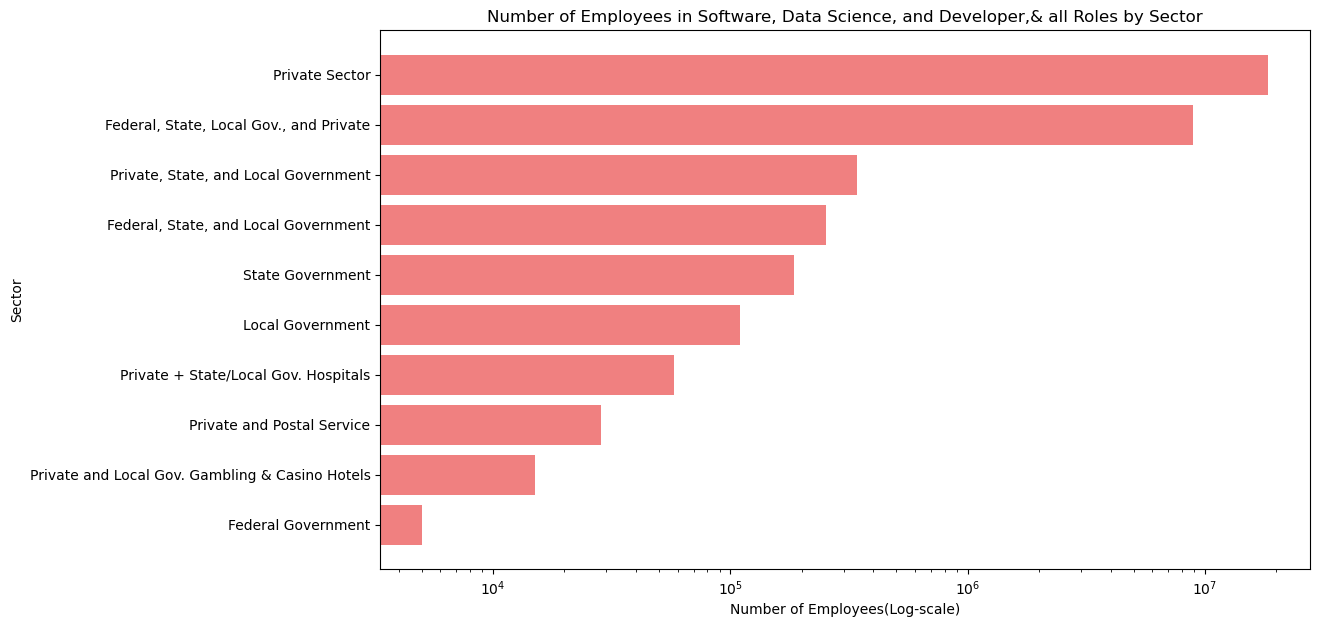

In [139]:
# Group by OWN_CODE and sum the total employees for each sector
sector_data = filtered_data.groupby('OWN_CODE')['TOT_EMP'].sum().reset_index()

# Map OWN_CODE according to description
ownership_mapping = {
    1: 'Federal Government',
    2: 'State Government',
    3: 'Local Government',
    123: 'Federal, State, and Local Government',
    235: 'Private, State, and Local Government',
    35: 'Private and Local Government',
    5: 'Private Sector',
    57: 'Private and Local Gov. Gambling & Casino Hotels',
    58: 'Private + State/Local Gov. Hospitals',
    59: 'Private and Postal Service',
    1235: 'Federal, State, Local Gov., and Private'
}

# Replace OWN_CODE with 
sector_data['OWN_CODE'] = sector_data['OWN_CODE'].replace(ownership_mapping)


sector_data = sector_data.sort_values(by='TOT_EMP')

# Plot the data
plt.figure(figsize=(12, 7))
plt.barh(sector_data['OWN_CODE'], sector_data['TOT_EMP'], color='lightcoral')
plt.xlabel('Number of Employees(Log-scale)')
plt.ylabel('Sector')
plt.title('Number of Employees in Software, Data Science, and Developer,& all Roles by Sector')
#log to see all the bars due to large number some were unnoticalbe 
plt.xscale('log') 
plt.show()
#Demi (2022)

### Objective of this visualization
The objective of this visualization was a comparison between different sector and how many people are working in those sectors.And This was only for filtered fields job related to software and others.
### Why this type was chosen
The horizontal bar chart was chosen because it enables the viewer to effortlessly compare the number of employees by ownership types.As bar chat are great in comparing the categories  so we used this one pie was another optiion but details were not clear dua to many sectors and less numbers. While there is a great difference in the number of employees from each sector, the log scale was applied to the x-axis so that all bars, also the ones with low employment numbers, are visible.So use of log scale came up in that kind of situations so used on employees for that.
### Why we learned
We can see a huge trend in private sector which mean alot of people want to work in private companies, as compare to fedral govt. Also we can see there is alot of involvement in public sector like hospitales and state and local governments. We can see that minimum 3 sector are combined as  Federal, State, Local Gov. if we leave then in anaylsis we can see the most is privte then state and local govt, then hospitals and casions and last one is federal Government segments.As we have seen or read about rules and regulations of the use and implementaion of AI where we seen private companies are more using it then government institutes so that could be a reason of low number of employees in here

# Question 3 
## How many workers from each software job are working in each sector?

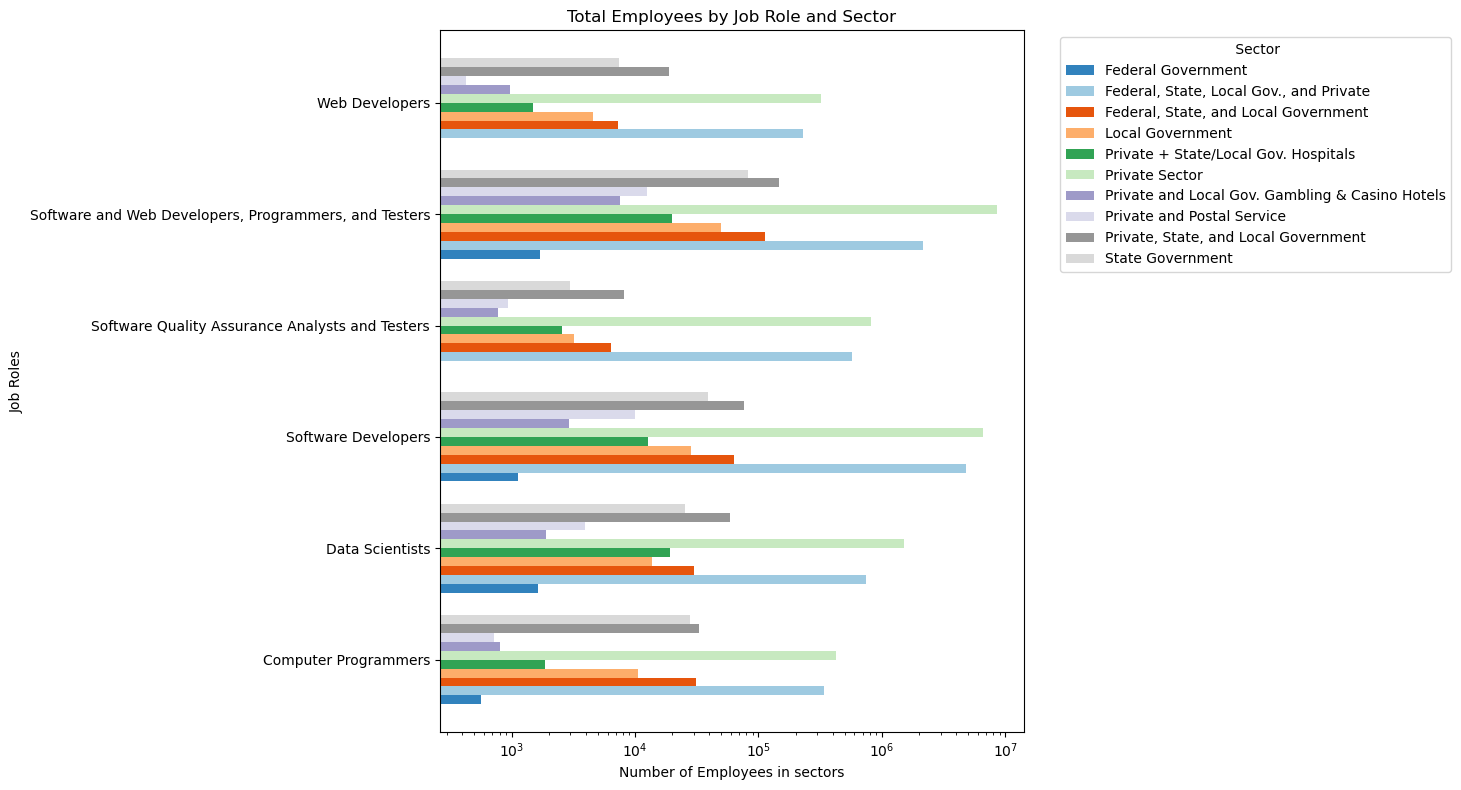

In [141]:
# Group data by OWN_CODE (sector) and OCC_TITLE (job role) to sum the total employees
sector_job_data = filtered_data.groupby(['OWN_CODE', 'OCC_TITLE'])['TOT_EMP'].sum().reset_index()

sector_job_data['OWN_CODE'] = sector_job_data['OWN_CODE'].replace(ownership_mapping)

# Pivot the table to create a matrix where each row is a job and each column is a sector
pivot_data = sector_job_data.pivot(index='OCC_TITLE', columns='OWN_CODE', values='TOT_EMP')

# Plot a horizontal grouped bar chart with logarithmic scale
pivot_data.plot(kind='barh', figsize=(15, 8), cmap='tab20c', width=0.8)

plt.title('Total Employees by Job Role and Sector')
plt.xlabel('Number of Employees in sectors')
plt.ylabel('Job Roles')
plt.xscale('log')
plt.legend(title=' Sector', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
#Jonathan Soma (2021)

### Objective of this visualization
The objective of this visualization was a comparison to see the trend workers in different job in different sectors.To see what kind of job title is attracted in what sector
### Why this type was chosen
The grouped horizontal bar chart was chosen because we can see different color representing different number of employees in sectors.Doing horizontal will allow us to read full job name alongs with a fine length of bar height so conclude our results. Due to large variations in employee counts across jobs and sectors, a logarithmic scale was used to display these differences effectively.
### Why we learned
we can see that from different field worker take slight a differert trend of picking sector.But as we see in above chat private is hight in all. Also we can see there is minimal amount web developer working for fedral govt(strange!).But here we see that Data Scientist are more then any other job in federal.This could be due to government tend to do new reseach and involve in more sreaches. Data scientist is a huge part of Ai things.

# Question 4 
## what is the yearly mean salary in these jobs?

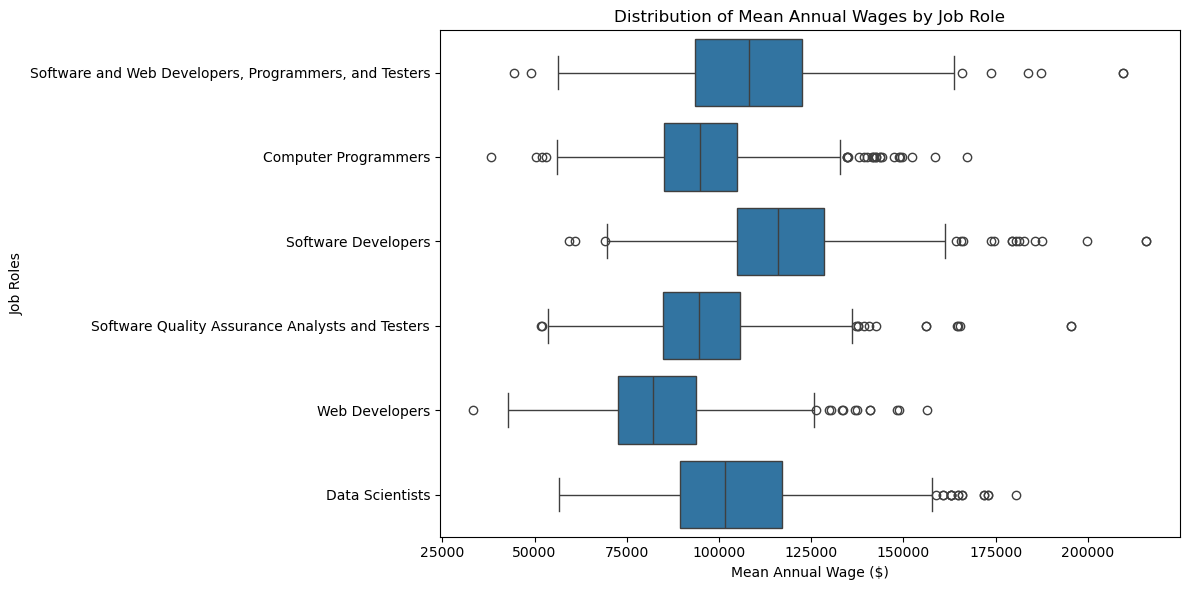

In [108]:
#To see what is the average mean salary we will plot a histogram distribution and a box plot
# Box plot to visualize wage distribution for each filtered job role
filtered_data.loc[:, 'A_MEAN'] = pd.to_numeric(filtered_data['A_MEAN'], errors='coerce')
plt.figure(figsize=(12, 6))
sns.boxplot(data=filtered_data, x='A_MEAN', y='OCC_TITLE')
plt.title('Distribution of Mean Annual Wages by Job Role')
plt.xlabel('Mean Annual Wage ($)')
plt.ylabel('Job Roles')
plt.tight_layout()
plt.show()

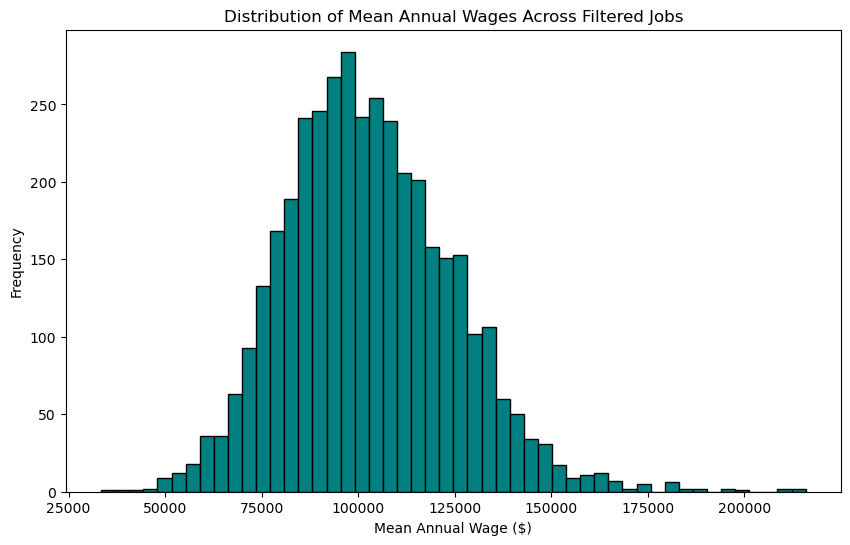

In [110]:
# Plot the histogram for annual wages across the filtered jobs

plt.figure(figsize=(10, 6))
plt.hist(filtered_data['A_MEAN'].dropna(), bins=50, color='teal', edgecolor='black')
plt.title('Distribution of Mean Annual Wages Across Filtered Jobs')
plt.xlabel('Mean Annual Wage ($)')
plt.ylabel('Frequency')
plt.show()


### Objective of this visualization
The objective of this plots is to investigate the distribution of mean annual wages accross different job roles in the filtere dataset which is foucsing Data Science, and Software-related roles. This inculudes understanding the salary range for each role and comparing how the salaries are distributed across different jobs.
### Why this type was chosen
Box plot: It was choosen because it provide clear summary of wages distribution for each job role. it exculde the outlier if any exsit. It shows key statistics such as the median, interquartile range (IQR) make easy to comapre wage for different sector.

Histogram: we know they are good for distributed data. So histogram was for visualizing the frequency distribution of mean annual wages across all filtered jobs. It gives a clear view of how wages are spread over different ranges 
### Why we learned
we can see from box plot that which job role has what range of wage.As we can see software developer have more pay so we can say that could be the reason of more people in that role.And Histogram was for wage distribution of all the filtered job(means software and data science ) related job to overall see start and end of yearly pay.We can also observe that salaries for software and data scientist are kind of more then other which can show a huge up trend in Ai feild in upcomming year as compare to web develpment or computer programmers.

# Challange Task
For this task, I would like to compare total employees in assignment related fields to see any increse or decrese in trend

In [114]:
# so i would read my xlsx files for 2021 and 2022 as we alrealy have 2023 
data_2021 = pd.read_excel('all_data_M_2021.xlsx')
data_2022 = pd.read_excel('all_data_M_2022.xlsx')



In [115]:
# Filter the data for each year to only include specified job titles
job_titles = 'Software|Data Scientist|Developer|Computer Programmer'
filtered_data_2021 = data_2021[data_2021['OCC_TITLE'].str.contains(job_titles, case=False, na=False)]
filtered_data_2022 = data_2022[data_2022['OCC_TITLE'].str.contains(job_titles, case=False, na=False)]

In [116]:
# Convert 'TOT_EMP' to numeric safely using .loc to suppress SettingWithCopyWarning
filtered_data_2021.loc[:, 'TOT_EMP'] = pd.to_numeric(filtered_data_2021['TOT_EMP'], errors='coerce')
filtered_data_2022.loc[:, 'TOT_EMP'] = pd.to_numeric(filtered_data_2022['TOT_EMP'], errors='coerce')

# Sum the total employees for each job title per year
total_emp_2021 = filtered_data_2021.groupby('OCC_TITLE')['TOT_EMP'].sum().reset_index()
total_emp_2022 = filtered_data_2022.groupby('OCC_TITLE')['TOT_EMP'].sum().reset_index()
total_emp_2023 = filtered_data.groupby('OCC_TITLE')['TOT_EMP'].sum().reset_index()

# Add a year column for easy comparison
total_emp_2021['Year'] = 2021
total_emp_2022['Year'] = 2022
total_emp_2023['Year'] = 2023

In [117]:
# Combine data for all years
combined_data = pd.concat([total_emp_2021, total_emp_2022, total_emp_2023], ignore_index=True)
# Check the combined data
#print(combined_data)

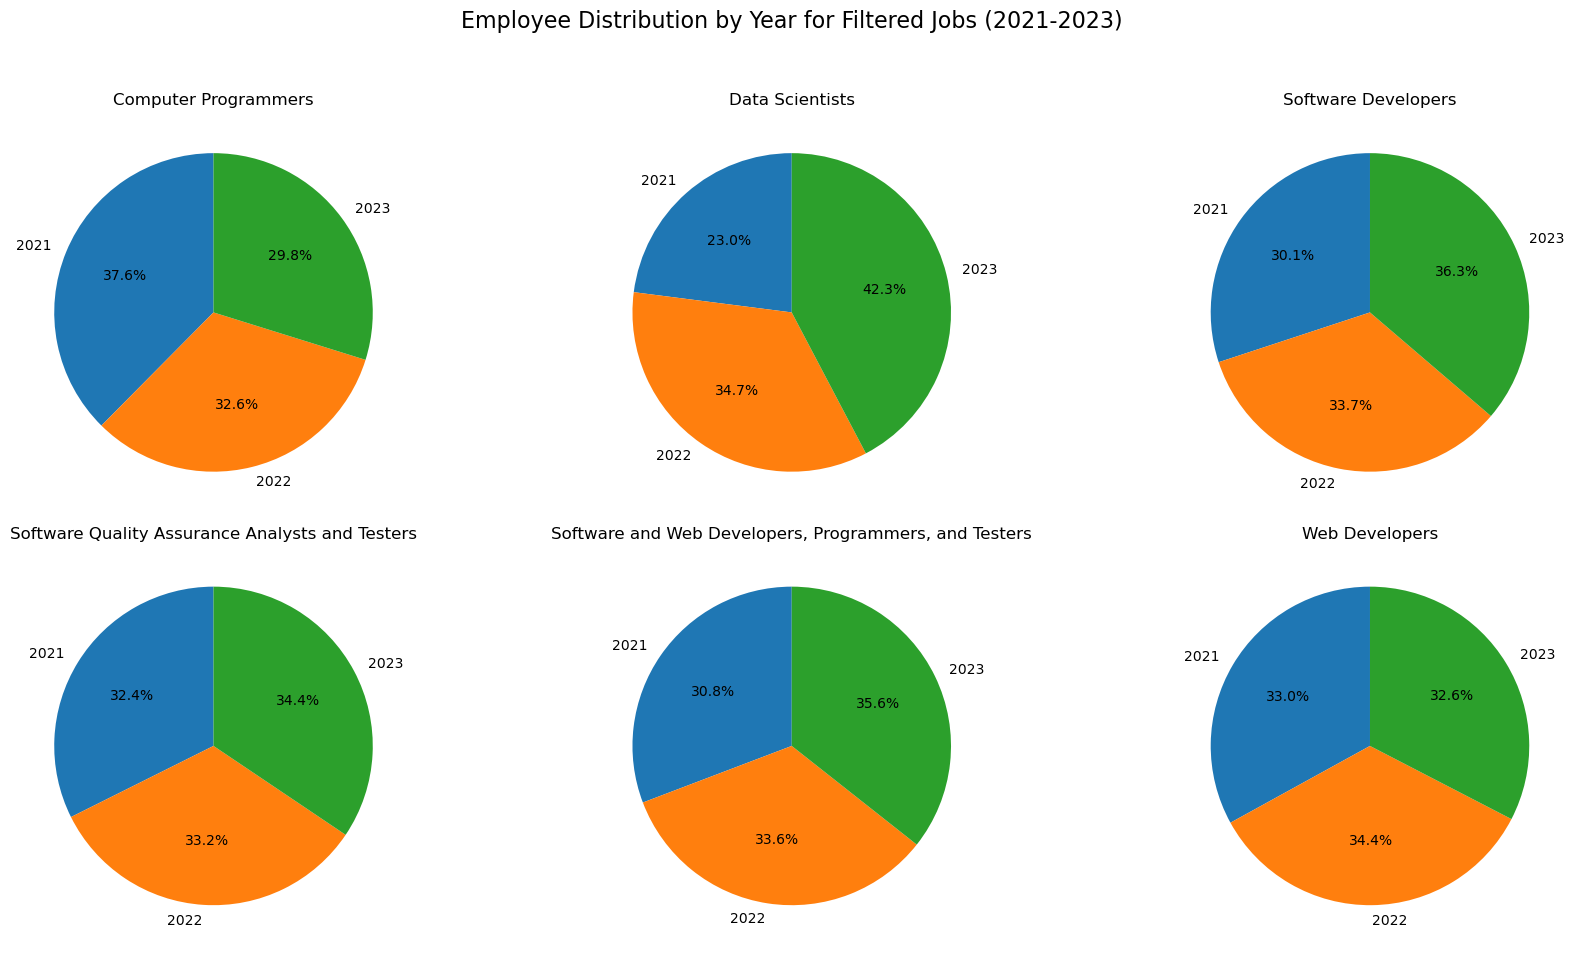

In [118]:

# List of unique job titles
job_titles = combined_data['OCC_TITLE'].unique()

# Set up the figure with subplots (adjust layout based on number of job titles)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # Modify the layout if you have more or fewer jobs
axes = axes.flatten()

# Iterate over each job title and corresponding axis to create pie charts
for i, (job, ax) in enumerate(zip(job_titles, axes)):
    # Filter data for the specific job title
    job_data = combined_data[combined_data['OCC_TITLE'] == job]
    
    # Sort by year to keep the order consistent
    job_data = job_data.sort_values(by='Year')
    
    # Values and labels for the pie chart
    values = job_data['TOT_EMP']
    labels = job_data['Year'].astype(str)
    
    # Plot the pie chart for the job
    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
    ax.set_title(job)

# Adjust layout and display
plt.suptitle('Employee Distribution by Year for Filtered Jobs (2021-2023)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust spacing to fit suptitle
plt.show()



### Objective of this visualization
The objective of this plots is to investigate and compare the number of employees in software or computer fields .This shows how how employment numbers in various AI-related roles (such as software developers, data scientists, and web developers) have changed over a three-year period (2021-2023). By breaking down total employment by year for each job title, this visualization helps us identify trends in job growth or decline across the AI and tech fields.
### Why this type was chosen
Pie charts were chosen for this visualization because they allow for a clear comparison of proportions within each job title across years. They help quickly illustrate the relative distribution of employees across the three years. By arranging multiple pie charts as subplots, we can visualize each job independently while maintaining consistent format across all job titles, making trends easier to interpret and compare.
### Why we learned
we learned about the trends in AI employment over the three years for various roles. By comparing slices of each pie, we can see which roles experienced growth or decline. some roles may show a steady increase in employment year-over-year, indicating a growing demand, while others display a more static distribution. This help us to see the more attached field of computer to Ai has gone up in job although every things is connected one way or other but we can see web developers and computer programmers have a slight decrese but data scientist and software shown a good growth

## Reference list
Jonathan Soma (2021). How to make grouped bar charts in pandas/Python with crosstab and pivot tables and more. [online] YouTube. Available at: https://www.youtube.com/watch?v=O4538i9MQEc [Accessed 24 Oct. 2024].

Demi (2022). Python data visualization: too small value to be visible - how to solve? [online] Stack Overflow. Available at: https://stackoverflow.com/questions/72255652/python-data-visualization-too-small-value-to-be-visible-how-to-solve [Accessed 24 Oct. 